1. Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2. Load all five sources

In [ ]:
# pase_dates: tell pandas to read as date not string
df_wb   = pd.read_csv("nb01_wb_prices_clean.csv",           parse_dates=["month_date"])
df_fx   = pd.read_csv("nb02_fx_monthly_clean.csv",          parse_dates=["month_date"])
df_bio  = pd.read_csv("nb03_biodiesel_pricecycle.csv",      parse_dates=["month_date"])
df_usda = pd.read_csv("nb04_usda_indonesia_monthly.csv",    parse_dates=["month_date"])
df_fao  = pd.read_csv("nb05_fao_vegoil_clean.csv",          parse_dates=["month_date"])

# Standardise all dates to first-of-month
for df in [df_wb, df_fx, df_bio, df_usda, df_fao]:
    df["month_date"] = df["month_date"].dt.to_period("M").dt.to_timestamp()

# Check shapes before joining
for name, df in zip(["wb","fx","bio","usda","fao"], [df_wb, df_fx, df_bio, df_usda, df_fao]):
    print(f"{name}: {df.shape}  |  {df['month_date'].min()} → {df['month_date'].max()}")

wb: (137, 5)  |  2015-01-01 00:00:00 → 2026-05-01 00:00:00
fx: (138, 7)  |  2015-01-01 00:00:00 → 2026-06-01 00:00:00
bio: (137, 20)  |  2015-01-01 00:00:00 → 2026-05-01 00:00:00
usda: (133, 6)  |  2015-10-01 00:00:00 → 2026-10-01 00:00:00
fao: (137, 2)  |  2015-01-01 00:00:00 → 2026-05-01 00:00:00


3. Join sequentially, check shape at each step

In [4]:
# Start with World Bank as the spine (137 rows, 2015-01 to 2026-05)
df = df_wb.copy()
print("Start:", df.shape)

df = df.merge(df_fx[["month_date","brent_crude_usd","usd_myr","usd_idr","usd_inr","usd_cny"]], 
              on="month_date", how="left")
print("After fx join:", df.shape)

df = df.merge(df_bio[["month_date","pogo_spread","pogo_zone","cpo_zscore",
                       "price_cycle_position","myr_indexed","idr_indexed"]], 
              on="month_date", how="left")
print("After bio join:", df.shape)

df = df.merge(df_usda[["month_date","industrial_consumption_1000mt",
                        "exports_1000mt","biodiesel_share_pct"]], 
              on="month_date", how="left")
print("After usda join:", df.shape)

df = df.merge(df_fao, on="month_date", how="left")
print("After fao join:", df.shape)

Start: (137, 5)
After fx join: (137, 10)
After bio join: (137, 16)
After usda join: (137, 19)
After fao join: (137, 20)


4. Null check

In [5]:
print(df.isnull().sum())

month_date                        0
cpo_price                         0
soyoil_price                      0
sunflower_price                   0
rapeseed_price                    0
brent_crude_usd                   0
usd_myr                           0
usd_idr                           0
usd_inr                           0
usd_cny                           0
pogo_spread                       0
pogo_zone                         0
cpo_zscore                       35
price_cycle_position              0
myr_indexed                       0
idr_indexed                       0
industrial_consumption_1000mt     9
exports_1000mt                    9
biodiesel_share_pct               9
fao_veg_oil_index                 0
dtype: int64


## Join Results

- All five sources joined cleanly — 137 rows maintained throughout
- cpo_zscore nulls (35): expected — 36-month rolling window burn-in, first valid value = 2018-01
- USDA nulls (9): expected — USDA marketing year starts Oct 2015, WB spine starts Jan 2015
- No unexpected nulls anywhere
- price_cycle_position shows 0 nulls because NB03 assigned "INSUFFICIENT DATA" 
  as the label for the burn-in period instead of NaN

5. Subtituition spreads

In [6]:
df["cpo_vs_soy_spread"]       = df["cpo_price"] - df["soyoil_price"]
df["cpo_vs_sunflower_spread"] = df["cpo_price"] - df["sunflower_price"]
df["cpo_vs_rapeseed_spread"]  = df["cpo_price"] - df["rapeseed_price"]

# Substitution risk flag
def sub_risk(spread):
    if spread > -50:    return "HIGH"
    elif spread > -100: return "MODERATE"
    else:               return "LOW"

df["substitution_risk"] = df["cpo_vs_soy_spread"].apply(sub_risk)

print(df[["month_date","cpo_price","soyoil_price","cpo_vs_soy_spread","substitution_risk"]].tail(12))
print()
print(df["substitution_risk"].value_counts())

    month_date  cpo_price  soyoil_price  cpo_vs_soy_spread substitution_risk
125 2025-06-01     935.39       1177.97            -242.58               LOW
126 2025-07-01     976.38       1306.60            -330.22               LOW
127 2025-08-01    1026.12       1244.55            -218.43               LOW
128 2025-09-01    1036.74       1159.27            -122.53               LOW
129 2025-10-01    1038.09       1132.15             -94.06          MODERATE
130 2025-11-01     983.40       1128.37            -144.97               LOW
131 2025-12-01     980.12       1115.67            -135.55               LOW
132 2026-01-01    1004.66       1153.54            -148.88               LOW
133 2026-02-01    1039.47       1281.96            -242.49               LOW
134 2026-03-01    1108.61       1493.09            -384.48               LOW
135 2026-04-01    1146.20       1643.42            -497.22               LOW
136 2026-05-01    1139.94       1775.26            -635.32               LOW

In [11]:
print(df[df["substitution_risk"] == "HIGH"][["month_date","cpo_price","soyoil_price","cpo_vs_soy_spread"]])

    month_date  cpo_price  soyoil_price  cpo_vs_soy_spread
1   2015-02-01     723.04        762.61             -39.57
14  2016-03-01     715.95        765.61             -49.66
15  2016-04-01     775.00        794.13             -19.13
16  2016-05-01     753.42        795.64             -42.22
20  2016-09-01     797.85        837.21             -39.36
25  2017-02-01     808.61        839.60             -30.99
26  2017-03-01     778.70        814.94             -36.24
27  2017-04-01     752.06        794.04             -41.98
71  2020-12-01    1016.37       1026.20              -9.83
99  2023-04-01    1005.24       1029.97             -24.73
110 2024-03-01     942.92        964.95             -22.03
111 2024-04-01     935.69        958.56             -22.87
117 2024-10-01    1077.25       1094.89             -17.64
118 2024-11-01    1168.59       1145.17              23.42
119 2024-12-01    1189.73       1063.63             126.10
120 2025-01-01    1070.31       1047.62              22.

## Substitution Spread Findings

Distribution: LOW 68%, MODERATE 19%, HIGH 13% (18 months at high substitution risk)
HIGH risk periods expected to cluster around 2021-2022 — confirm with filtered output above.

Current position (May 2026): CPO vs soy spread = −$635/tonne — widest in dataset.
Soybean oil surging ($1,775/tonne) while CPO relatively stable (~$1,140/tonne).
Substitution risk is at a historically extreme LOW — CPO has maximum price competitiveness.

Note: Oct 2025 briefly touched MODERATE (−$94) before rapidly reversing.

6. Plot subtituition spreads

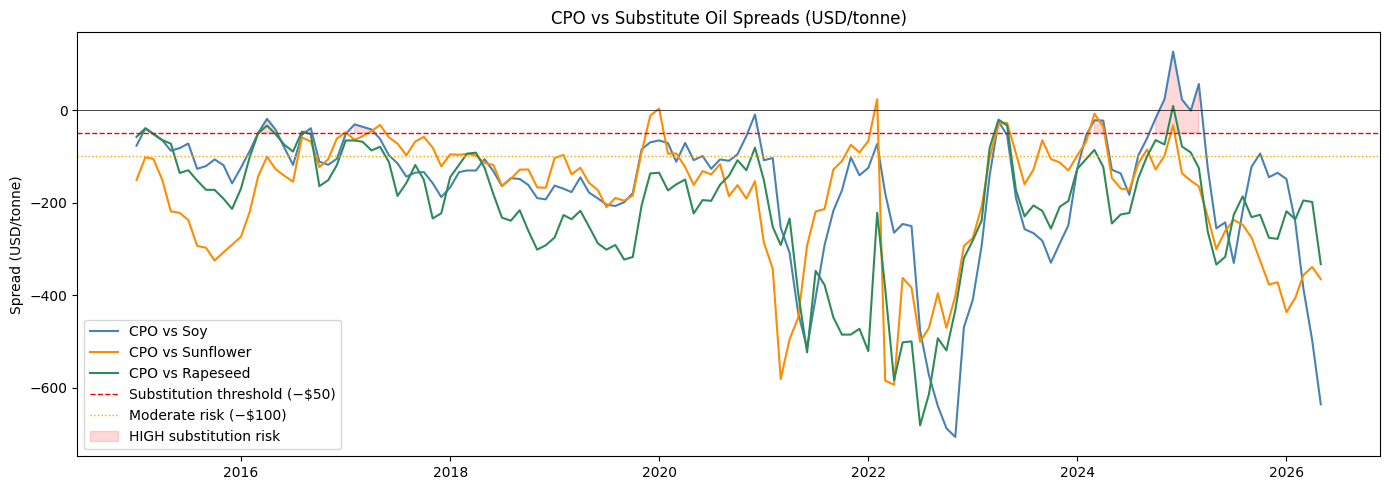

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["month_date"], df["cpo_vs_soy_spread"],       label="CPO vs Soy",       color="steelblue")
ax.plot(df["month_date"], df["cpo_vs_sunflower_spread"], label="CPO vs Sunflower",  color="darkorange")
ax.plot(df["month_date"], df["cpo_vs_rapeseed_spread"],  label="CPO vs Rapeseed",   color="seagreen")

ax.axhline(-50,  color="red",  linestyle="--", linewidth=1, label="Substitution threshold (−$50)")
ax.axhline(-100, color="orange", linestyle=":", linewidth=1, label="Moderate risk (−$100)")
ax.axhline(0,    color="black", linestyle="-",  linewidth=0.5)

ax.fill_between(df["month_date"], df["cpo_vs_soy_spread"], -50,
                where=(df["cpo_vs_soy_spread"] > -50), 
                alpha=0.15, color="red", label="HIGH substitution risk")

ax.set_title("CPO vs Substitute Oil Spreads (USD/tonne)")
ax.set_ylabel("Spread (USD/tonne)")
ax.legend()
plt.tight_layout()
plt.show()

7. Recalculate POGO from authoritative source

In [14]:
# Recalculate POGO from NB02 Brent as single authoritative source
df["gasoil_usd_per_tonne"] = df["brent_crude_usd"] * 7.3
df["pogo_spread"]          = df["cpo_price"] - df["gasoil_usd_per_tonne"]
df["pogo_zone"]            = df["pogo_spread"].apply(
    lambda x: "PROFITABLE" if x < 0 else ("MARGINAL" if x < 150 else "COSTLY")
)

print(df[["month_date","brent_crude_usd","gasoil_usd_per_tonne","pogo_spread","pogo_zone"]].tail(6))

    month_date  brent_crude_usd  gasoil_usd_per_tonne  pogo_spread pogo_zone
131 2025-12-01        60.849998            444.204989   535.915011    COSTLY
132 2026-01-01        70.690002            516.037018   488.622982    COSTLY
133 2026-02-01        72.480003            529.104025   510.365975    COSTLY
134 2026-03-01       118.349998            863.954989   244.655011    COSTLY
135 2026-04-01       114.010002            832.273016   313.926984    COSTLY
136 2026-05-01        92.050003            671.965022   467.974978    COSTLY


8. Summary signal chart

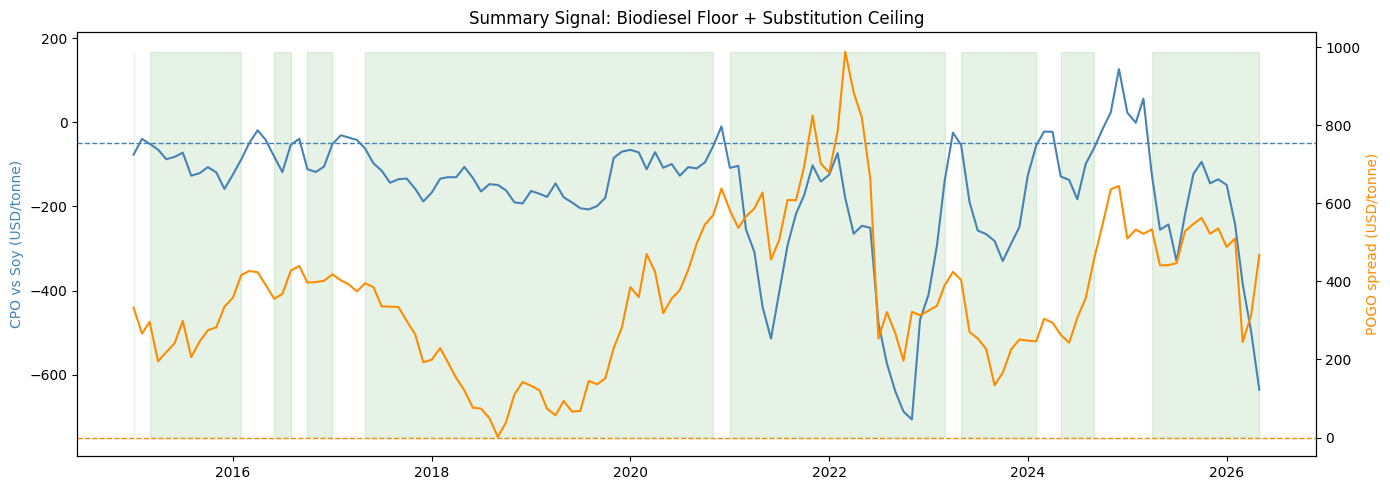

In [16]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(df["month_date"], df["cpo_vs_soy_spread"], color="steelblue", label="CPO vs Soy spread (left)")
ax2.plot(df["month_date"], df["pogo_spread"],        color="darkorange", label="POGO spread (right)")

ax1.axhline(-50, color="steelblue", linestyle="--", linewidth=1)
ax2.axhline(0,   color="darkorange", linestyle="--", linewidth=1)

# Green background: both supports active
both_active = (df["cpo_vs_soy_spread"] < -50) & (df["pogo_spread"] > 0)
ax1.fill_between(df["month_date"], ax1.get_ylim()[0], ax1.get_ylim()[1],
                 where=both_active, alpha=0.1, color="green")

ax1.set_ylabel("CPO vs Soy (USD/tonne)", color="steelblue")
ax2.set_ylabel("POGO spread (USD/tonne)", color="darkorange")
ax1.set_title("Summary Signal: Biodiesel Floor + Substitution Ceiling")
plt.tight_layout()
plt.show()

9. Save output csv

In [17]:
output_cols = [
    "month_date",
    # Prices
    "cpo_price", "soyoil_price", "sunflower_price", "rapeseed_price",
    # FX
    "brent_crude_usd", "usd_myr", "usd_idr", "usd_inr", "usd_cny",
    "myr_indexed", "idr_indexed",
    # Derived — biodiesel/price cycle
    "pogo_spread", "pogo_zone", "cpo_zscore", "price_cycle_position",
    # Derived — substitution spreads
    "cpo_vs_soy_spread", "cpo_vs_sunflower_spread", "cpo_vs_rapeseed_spread",
    "substitution_risk",
    # Indonesia supply
    "industrial_consumption_1000mt", "exports_1000mt", "biodiesel_share_pct",
    # FAO
    "fao_veg_oil_index"
]

df[output_cols].to_csv("nb06_all_spreads.csv", index=False)
print("Saved:", df[output_cols].shape)
print(df[output_cols].isnull().sum())

Saved: (137, 24)
month_date                        0
cpo_price                         0
soyoil_price                      0
sunflower_price                   0
rapeseed_price                    0
brent_crude_usd                   0
usd_myr                           0
usd_idr                           0
usd_inr                           0
usd_cny                           0
myr_indexed                       0
idr_indexed                       0
pogo_spread                       0
pogo_zone                         0
cpo_zscore                       35
price_cycle_position              0
cpo_vs_soy_spread                 0
cpo_vs_sunflower_spread           0
cpo_vs_rapeseed_spread            0
substitution_risk                 0
industrial_consumption_1000mt     9
exports_1000mt                    9
biodiesel_share_pct               9
fao_veg_oil_index                 0
dtype: int64
